### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

In [1]:
import numpy as np

def simulate(N, epsilon, p):
    mu_0 = np.array([0, 0])
    mu_1 = np.array([epsilon, 0])
    cov_0 = np.array([[0.5, 0], [0, 0.5]])
    cov_1 = np.array([[0.4, 0], [0, 0.4]])
    D = np.zeros([N, 3])
    for i in range(N):
        if np.random.rand() < p:
            y = 1
            x = np.random.multivariate_normal(mu_1, cov_1, [1])
        else:
            y = 0
            x = np.random.multivariate_normal(mu_0, cov_0, [1])
        D[i, 0:2] = x
        D[i, 2] = y
    return D

N_train = 50
N_test = 1000
epsilon_train = 2
epsilon_test = 2
p_train = 0.3
p_test = 0.3
D_train = simulate(N_train, epsilon_train, p_train)
D_test = simulate(N_test, epsilon_test, p_test)

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

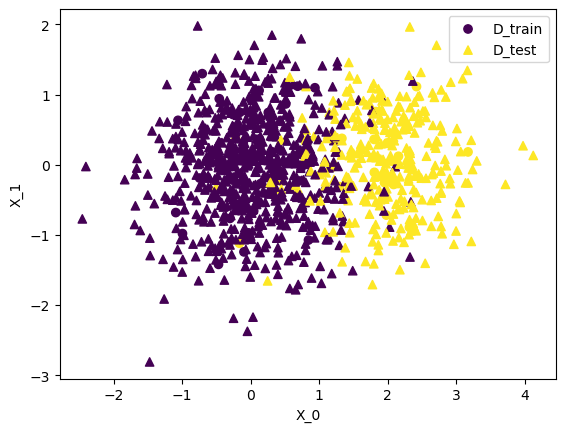

In [2]:
import matplotlib.pyplot as plt

X_train = D_train[:,:2]
y_train = D_train[:,2]
X_test = D_test[:,:2]
y_test = D_test[:,2]

plt.scatter(X_train[:,0], X_train[:,1], c=y_train, marker="o", label="D_train")
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker="^", label="D_test")
plt.xlabel("X_0")
plt.ylabel("X_1")
plt.legend()
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The probability is as follows: $Prob(Y=1|X\in\beta_{\epsilon}(\mathbf{x_0}))=\frac{1}{1 + \frac{p(\mathbf{x_0} | Y = 0)}{p(\mathbf{x_0} | Y = 1)}\frac{1-p}{p}}$

and the Bayes classifier is given by

\begin{equation}
    f(x) =
    \begin{cases}
    1 \text{ if } p(\mathbf{x}|Y=1)p > p(\mathbf{x}|Y=0)(1-p)\\
    0 \text{ otherwise}
    \end{cases}
\end{equation}

The boundary region is $\{x | p(\mathbf{x}|Y=1)p | p(\mathbf{x}|Y=0)(1-p)\}$

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [3]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from scipy.stats import multivariate_normal
from sklearn.metrics import mean_squared_error

class BayesClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self):
        pass

    def fit(self, X, y, N, epsilon, p):
        self.N_ = N
        self.epsilon_ = epsilon
        self.p_ = p
        # Return the classifier
        return self

    def predict(self, X):

        # Check if fit has been called
        check_is_fitted(self)

        mu_0 = np.array([0, 0])
        mu_1 = np.array([self.epsilon_, 0])
        cov_0 = np.array([[0.5, 0], [0, 0.5]])
        cov_1 = np.array([[0.4, 0], [0, 0.4]])

        prob_0 = multivariate_normal(mu_0, cov_0).pdf(X)
        prob_1 = multivariate_normal(mu_1, cov_1).pdf(X)

        y = np.array([1 if prob_1[i]*self.p_ > prob_0[i] * (1 - self.p_) else 0 for i in range(X.shape[0])])
        return y

In [4]:
N = 10000
epsilon = 2
p = 0.3
D = simulate(N, epsilon, p)
X = D[:,:2]
y = D[:,2]
predictions = BayesClassifier().fit(X, y, N, epsilon, p).predict(X)
error = mean_squared_error(y, predictions)
print(error)

0.0613


The error for the Bayes classifier is 0.0635.

I expect the error rate to increase for smaller values $\epsilon$, and decrease for larger values, since it controls the separation of the datapoints by changing the mean $\mu_0$.

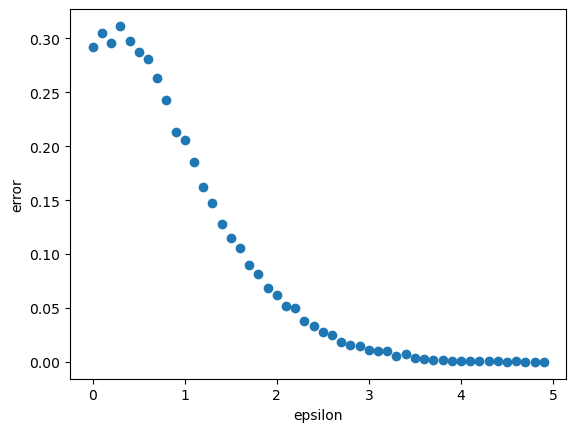

In [5]:
epsilon_values = [i / 10 for i in range(50)]

errors = []

for epsilon in epsilon_values:
    D = simulate(N, epsilon, p)
    X = D[:,:2]
    y = D[:,2]
    predictions = BayesClassifier().fit(X, y, N, epsilon, p).predict(X)
    error = mean_squared_error(y, predictions)
    errors.append(error)

plt.scatter(epsilon_values, errors)
plt.xlabel("epsilon")
plt.ylabel("error")
plt.show()

We can see that the error rate goes down the larger epsilon as expected.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

LDA assumes the data follows a Gaussian distribution and that the classes have a shared covariance. QDA assumes a Gaussian distribution but not shared covariance. Logistic regression assumes the posterior is a logistic function, which follows from a Gaussian distribution. 

The above datasets have a Gaussian distribution but have different covariances. Therefore QDA is the classifier that makes the strongest assumption that is true in the dataset, so it should be the most adequate.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
log_reg = LogisticRegression().fit(X_train, y_train)
bayes = BayesClassifier().fit(X_train, y_train, N_train, epsilon_train, p_train)

error_lda = mean_squared_error(y_test, lda.predict(X_test))
error_qda = mean_squared_error(y_test, qda.predict(X_test))
error_log = mean_squared_error(y_test, log_reg.predict(X_test))
error_bayes = mean_squared_error(y_test, bayes.predict(X_test))

print("Error for lda:", error_lda)
print("Error for qda:", error_qda)
print("Error for logistic regression:", error_log)
print("Error for bayes:", error_bayes)

Error for lda: 0.098
Error for qda: 0.107
Error for logistic regression: 0.099
Error for bayes: 0.069


The Bayes error is 0.048. LDA gives the largest error, 0.059, QDA gives a smaller error at 0.053, and logistic regression gives the smallest error at 0.049, which is very close to the Bayes error. I would expect the gap to be larger for smaller datasets and smaller for larger datasets, since the classifiers get more datapoints to train on, reducing the difference in information they have compared to the Bayes classifier.

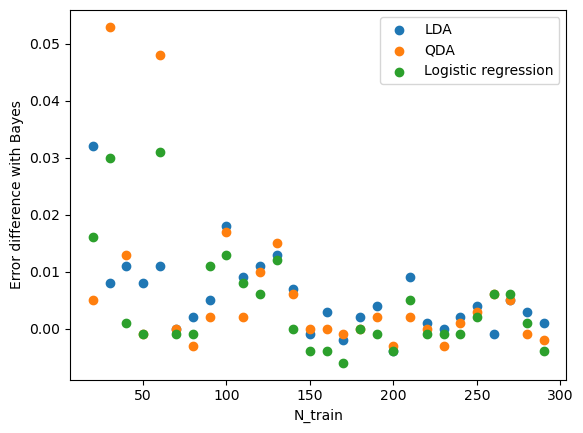

In [ ]:
bayes_lda_diffs = []
bayes_qda_diffs = []
bayes_log_diffs = []

N_train_values = range(20, 300, 10)

for N_train in N_train_values:
    D_train = simulate(N_train, 2, 0.3)
    X_train = D_train[:,:2]
    y_train = D_train[:,2]

    pred_lda = LinearDiscriminantAnalysis().fit(X_train, y_train).predict(X_test)
    pred_qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train).predict(X_test)
    pred_log = LogisticRegression().fit(X_train, y_train).predict(X_test)

    error_lda = mean_squared_error(y_test, pred_lda)
    error_qda = mean_squared_error(y_test, pred_qda)
    error_log = mean_squared_error(y_test, pred_log)

    pred_bayes = BayesClassifier().fit(X_train, y_train, N_train, 2, 0.3).predict(X_test)
    bayes_error = mean_squared_error(y_test, pred_bayes)


    bayes_lda_diffs.append(error_lda - bayes_error)
    bayes_qda_diffs.append(error_qda - bayes_error)
    bayes_log_diffs.append(error_log - bayes_error)

    # print(N_train)
    # print("Error for lda:", error_lda)
    # print("Error for qda:", error_qda)
    # print("Error for logistic regression:", error_log)

plt.scatter(N_train_values, bayes_lda_diffs, label="LDA")
plt.scatter(N_train_values, bayes_qda_diffs, label="QDA")
plt.scatter(N_train_values, bayes_log_diffs, label="Logistic regression")
plt.legend()
plt.xlabel("Number of training samples")
plt.ylabel("Error difference with Bayes")
plt.show()

We can see that as the number of training samples increase the error rate compared to the Bayes classifier goes down.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [8]:
D_test_prime = simulate(1000, 0.5, 0.7)
X_test_prime = D_test_prime[:,:2]
y_test_prime = D_test_prime[:,2]

pred_lda_prime = lda.predict(X_test_prime)
pred_qda_prime = qda.predict(X_test_prime)
pred_log_prime = log_reg.predict(X_test_prime)

error_lda_prime = mean_squared_error(y_test_prime, pred_lda_prime)
error_qda_prime = mean_squared_error(y_test_prime, pred_qda_prime)
error_log_prime = mean_squared_error(y_test_prime, pred_log_prime)

print("Error for lda on D_test:", error_lda_prime)
print("Error for qda on D_test:", error_qda_prime)
print("Error for logistic regression on D_test:", error_log_prime)

Error for lda on D_test: 0.541
Error for qda on D_test: 0.519
Error for logistic regression on D_test: 0.539


## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [9]:
import pandas as pd

input_dir = "data/"
train_data = pd.read_csv(input_dir + "train.csv")
test_data = pd.read_csv(input_dir + "test.csv")

# print(train_data.head())
# train_data.info()
# train_data.describe()
# print(train_data["Ticket"].value_counts())
# train_data = train_data.drop(columns=["Cabin", "Ticket", "Name"])
# test_data = test_data.drop(columns=["Cabin", "Ticket", "Name"])
X_train = train_data.drop(columns=["Survived"])
y_train = train_data["Survived"]
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
from skrub import tabular_pipeline

pipeline = tabular_pipeline("classification")
pipeline.fit(X_train, y_train)
transformed = pipeline.named_steps['tablevectorizer'].transform(X_train)
print(transformed.columns)

# print(pipeline.score(X_train, y_train))
predictions = pipeline.predict(test_data)
predictions_df = pd.DataFrame({"PassengerId": test_data["PassengerId"], "Survived": predictions})
predictions_df.to_csv("predictions.csv", index=False)

Index(['PassengerId', 'Pclass', 'Name_00', 'Name_01', 'Name_02', 'Name_03',
       'Name_04', 'Name_05', 'Name_06', 'Name_07', 'Name_08', 'Name_09',
       'Name_10', 'Name_11', 'Name_12', 'Name_13', 'Name_14', 'Name_15',
       'Name_16', 'Name_17', 'Name_18', 'Name_19', 'Name_20', 'Name_21',
       'Name_22', 'Name_23', 'Name_24', 'Name_25', 'Name_26', 'Name_27',
       'Name_28', 'Name_29', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket_00',
       'Ticket_01', 'Ticket_02', 'Ticket_03', 'Ticket_04', 'Ticket_05',
       'Ticket_06', 'Ticket_07', 'Ticket_08', 'Ticket_09', 'Ticket_10',
       'Ticket_11', 'Ticket_12', 'Ticket_13', 'Ticket_14', 'Ticket_15',
       'Ticket_16', 'Ticket_17', 'Ticket_18', 'Ticket_19', 'Ticket_20',
       'Ticket_21', 'Ticket_22', 'Ticket_23', 'Ticket_24', 'Ticket_25',
       'Ticket_26', 'Ticket_27', 'Ticket_28', 'Ticket_29', 'Fare', 'Cabin_00',
       'Cabin_01', 'Cabin_02', 'Cabin_03', 'Cabin_04', 'Cabin_05', 'Cabin_06',
       'Cabin_07', 'Cabin_08', 'Cabin_09

The `skrub` `tabular_pipeline` encodes the low cardinality predictors, such as Age, Sex, and Fare as categorical predictors, and encodes the high cardinality predictors, which are Name, Ticket and Cabin, using StringEncoder. StringEncoder performs a vectorization and singular value decomposition of the strings to represent them using 30 components.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "rf": RandomForestClassifier(),
    "gb": GradientBoostingClassifier(),
    "lr": LogisticRegression()
}

for model_name, model in models.items():
    pipeline = tabular_pipeline(model)
    print(pipeline)
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(test_data)
    predictions_df = pd.DataFrame({"PassengerId": test_data["PassengerId"], "Survived": predictions})
    predictions_df.to_csv(f"predictions_{model_name}.csv", index=False)

Pipeline(steps=[('tablevectorizer',
                 TableVectorizer(low_cardinality=OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                unknown_value=-1))),
                ('randomforestclassifier', RandomForestClassifier())])
Pipeline(steps=[('tablevectorizer',
                 TableVectorizer(datetime=DatetimeEncoder(periodic_encoding='spline'))),
                ('simpleimputer', SimpleImputer(add_indicator=True)),
                ('squashingscaler', SquashingScaler(max_absolute_value=5)),
                ('gradientboostingclassifier', GradientBoostingClassifier())])
Pipeline(steps=[('tablevectorizer',
                 TableVectorizer(datetime=DatetimeEncoder(periodic_encoding='spline'))),
                ('simpleimputer', SimpleImputer(add_indicator=True)),
                ('squashingscaler', SquashingScaler(max_absolute_value=5)),
                ('logisticregression', LogisticRegression())])


After trying a few different classifiers with skrub, I found that the default, `GradientBoostingClassifier`, gave the best score of 0.82057. My placement on the leaderboard with it was 304th.